# Méthode 

Pour classer efficacement les exoplanètes, nous avons suivi une démarche logique en quatre étapes. Tout d'abord, comme les données mélangeaient des unités très différentes, comme des jours pour la période et des degrés pour la température, nous les avons transformées mathématiquement pour les rendre comparables sur une même échelle. Une fois les données prêtes, nous avons cherché à savoir combien de groupes naturels existaient. En utilisant deux méthodes de calcul distinctes, nous avons trouvé la même réponse : il y a cinq grandes familles d'objets dans ce catalogue.

Nous avons ensuite testé plusieurs algorithmes pour former ces cinq groupes. Nous avons éliminé les méthodes classiques car elles étaient trop rigides pour les formes complexes de l'espace, ainsi que celles qui supprimaient trop de données considérées comme du bruit. Notre choix final s'est porté sur le Clustering Spectral, car c'est la seule méthode capable de comprendre les courbes naturelles des données tout en classant la totalité des objets sans en rejeter aucun. Enfin, pour prouver que ce résultat est solide, nous avons vérifié visuellement et statistiquement que ces groupes sont bien réels et qu'ils ne sont pas le fruit du hasard.

# importation des Biblothèques et PCA sur les données

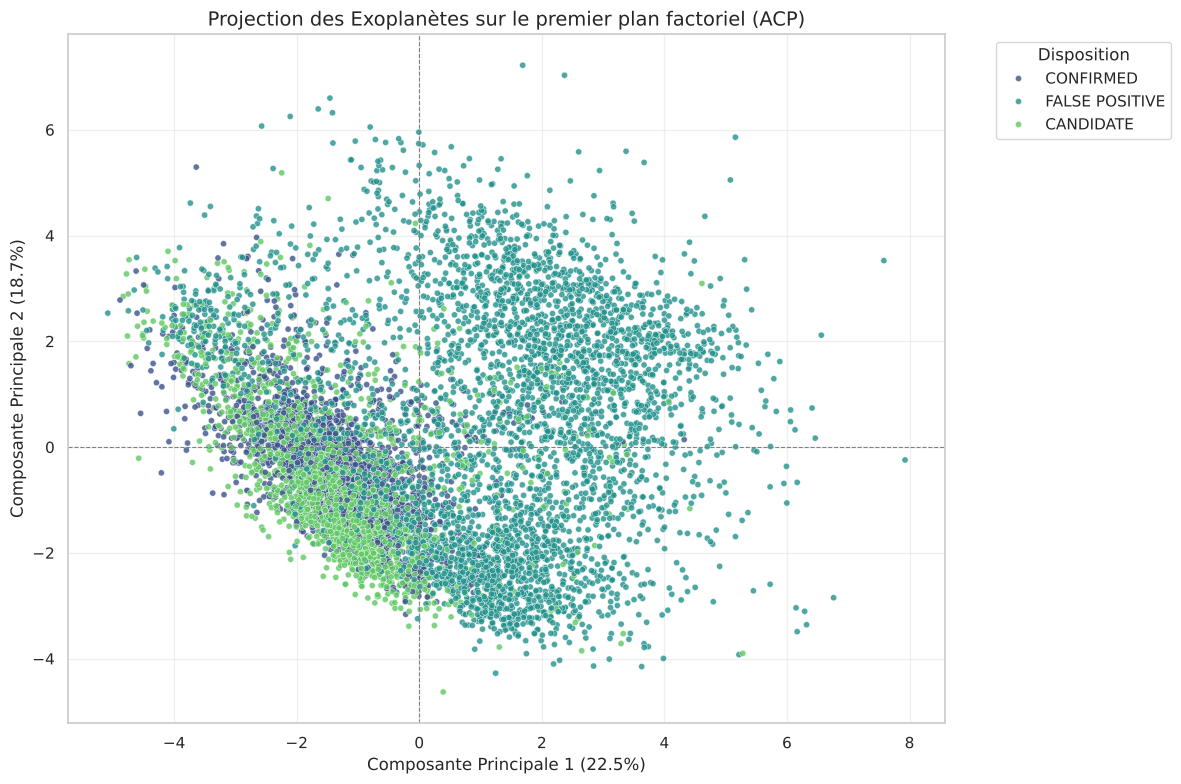

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering, AgglomerativeClustering,DBSCAN,HDBSCAN
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.neighbors import NearestNeighbors
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.linalg import eigsh
from scipy.sparse import csgraph


# Configuration pour des graphiques esthétiques
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


df = pd.read_csv("../data/cumulative_cleaned.csv")

# Sélection des colonnes pertinentes pour le clustering (Physique)
features = [
    'koi_score', 'koi_fpflag_nt', 'koi_fpflag_ss', 'koi_fpflag_co', 'koi_fpflag_ec',
    'koi_period', 'koi_time0bk', 'koi_impact', 'koi_duration', 'koi_depth',
    'koi_prad', 'koi_teq', 'koi_insol', 'koi_model_snr', 'koi_steff', 'koi_srad', 'ra', 'dec', 'koi_kepmag'
]


cols_to_log = features
for col in cols_to_log:
    if df[col].min() <= -1:
        df[col] = df[col] - df[col].min()
    df[col] = np.log1p(df[col])

X = df[features].copy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA() 
X_projected = pca.fit_transform(X_scaled)
plt.figure(figsize=(12, 8))


scatter = sns.scatterplot(
    x=X_projected[:, 0], 
    y=X_projected[:, 1], 
    hue=df['koi_disposition'], 
    palette='viridis', 
    alpha=0.8,    # Transparence pour voir les densités
    s=20          # Taille des points
)

# Ajout des axes zéro pour repère
plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100

plt.title('Projection des Exoplanètes sur le premier plan factoriel (ACP)', fontsize=14)
plt.xlabel(f'Composante Principale 1 ({var_pc1:.1f}%)', fontsize=12)
plt.ylabel(f'Composante Principale 2 ({var_pc2:.1f}%)', fontsize=12)

plt.legend(title='Disposition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

# DBSCAN

### Estimation des Paramètres DBSCAN : La Méthode du K-distance Plot
L'estimation du paramètre $\epsilon$ constitue une étape critique dans la configuration de l'algorithme DBSCAN. Ce paramètre détermine le rayon du voisinage, ou epsilon-ball, à l'intérieur duquel la densité locale est évaluée. Pour qu'un point soit identifié comme un noyau (core point), son voisinage doit contenir au moins un nombre min_samples de points. Par conséquent, le choix d'$\epsilon$ fixe implicitement le seuil de densité minimale détectable par le modèle. Afin de déterminer une valeur optimale pour ce rayon, nous utilisons la méthode heuristique du k-distance plot, aussi appelée méthode du coude.

D'un point de vue formel, considérons un jeu de données $X = \{x_i\}$ dans un espace $\mathbb{R}^d$. Pour une valeur entière $k$ correspondant au paramètre min_samples, la $k$-distance d'un point $x$ est définie comme la distance le séparant de son $k$-ième plus proche voisin. L'hypothèse fondamentale de cette méthode est qu'il existe une distinction structurelle entre les points appartenant à des clusters denses et ceux considérés comme du bruit. En ordonnant les $k$-distances de l'ensemble des points de manière croissante ($d_k(1) \le d_k(2) \le \dots \le d_k(n)$), le graphique résultant devrait faire apparaître une transition abrupte. Les faibles valeurs correspondent aux régions denses, tandis que l'élévation rapide des distances signale les zones éparses. Le point d'inflexion de cette courbe, ou "coude", fournit ainsi une estimation naturelle pour $\epsilon$.

La mise en œuvre technique de cette approche nécessite plusieurs étapes rigoureuses. Premièrement, il est impératif de normaliser les données, généralement par standardisation (z-score), afin de garantir qu'aucune variable ne domine le calcul des distances euclidiennes. Ensuite, l'algorithme des plus proches voisins (tel que sklearn.neighbors.NearestNeighbors) est exécuté pour extraire les distances $d_k$ pour chaque observation. Ces distances sont alors triées et tracées graphiquement. Pour les jeux de données volumineux, un sous-échantillonnage peut être appliqué afin de lisser la courbe et faciliter la lecture.

L'interprétation du graphique dépend fortement du choix initial de $k$ (min_samples). Les règles empiriques suggèrent généralement une valeur de $k \approx 2 \cdot d$ (où $d$ est la dimensionnalité effective des données), ou comprise entre 4 et 10 pour les faibles dimensions. Il est crucial de noter que la modification de $k$ impacte l'allure de la courbe : augmenter cette valeur tend à lisser le coude et à décaler le graphique vers des distances plus élevées, favorisant la détection de clusters plus volumineux et robustes. À l'inverse, un $k$ faible permet de capturer des micro-structures plus denses.

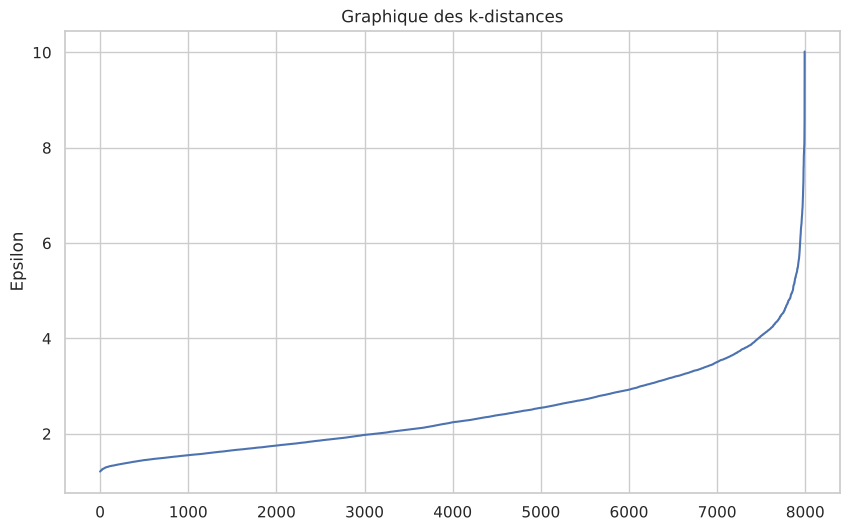

In [2]:

min_sample = 40# Règle empirique  2 * nombre de dimensions
neigh = NearestNeighbors(n_neighbors=min_sample)
neigh.fit(X_projected)
distances, _ = neigh.kneighbors(X_projected)

distances = np.sort(distances[:, min_sample-1])

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('Graphique des k-distances')
plt.ylabel('Epsilon')
plt.grid(True)
plt.show()

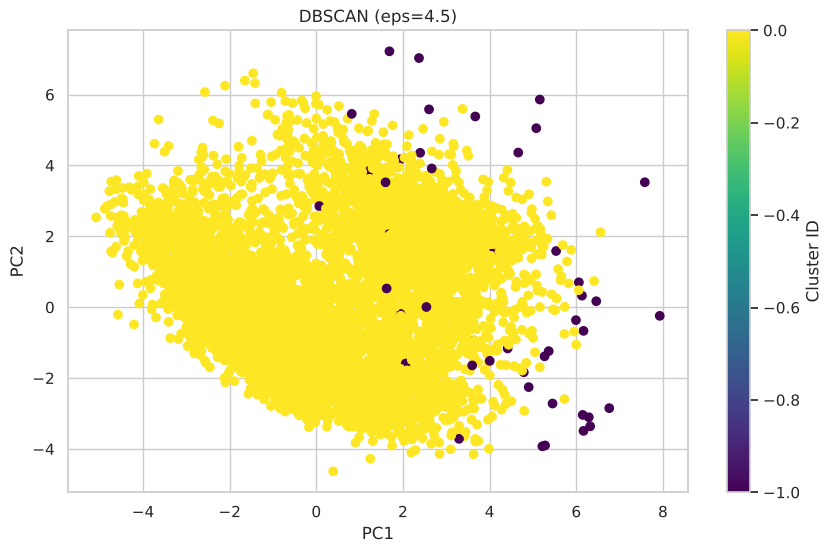

In [3]:
eps_optimal = 4.5

dbscan = DBSCAN(eps=eps_optimal, min_samples=min_sample)

clusters_dbscan = dbscan.fit_predict(X_projected) 

plt.figure(figsize=(10, 6))

scatter = plt.scatter(X_projected[:, 0], X_projected[:, 1], c=clusters_dbscan, cmap='viridis')
plt.colorbar(scatter, label='Cluster ID')
plt.title(f'DBSCAN (eps={eps_optimal})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [4]:
# Vérification du nombre de clusters ( -1 = Bruit)
print(pd.Series(clusters_dbscan).value_counts())

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# On filtre le bruit (-1) pour ne juger que les vrais groupes formés
mask = clusters_dbscan != -1

if len(set(clusters_dbscan[mask])) > 1: # On vérifie qu'il y a au moins 2 clusters trouvés
    X_eval = X_scaled[mask]
    labels_eval = clusters_dbscan[mask]
    print(f"Silhouette Score: {silhouette_score(X_eval, labels_eval):.3f}")
else:
    print("Pas assez de clusters pour calculer les scores.")

 0    7947
-1      47
Name: count, dtype: int64
Pas assez de clusters pour calculer les scores.


### Analyse des Résultats et Diagnostic d'Échec
L'exécution de l'algorithme a produit les statistiques suivantes :
- Cluster 0 : 7 947 observations.
- Bruit (-1) : 47 observations.

Le résultat démontre une segmentation inefficace, caractérisée par l'agglomération de 99,4 % des données au sein d'un cluster unique et massif. Le calcul des métriques de validation (Silhouette, Davies-Bouldin) est mathématiquement impossible car l'algorithme n'a pas réussi à scinder les données en au moins deux groupes distincts (hors bruit).
Pourquoi DBSCAN a-t-il échoué ici ?
Cet échec met en lumière une limitation fondamentale de DBSCAN lorsqu'il est appliqué à des données astrophysiques complexes :
1. Le problème de l'homogénéité de la densité : DBSCAN s'appuie sur un paramètre $\epsilon$ global et constant pour tout l'espace. Cela suppose implicitement que tous les clusters que l'on cherche à détecter possèdent une densité similaire. Or, nos données sont hétérogènes : le groupe des "vraies planètes" forme probablement un noyau très compact, tandis que les populations de binaires ou d'artefacts instrumentaux sont beaucoup plus diffuses.
2. L'effet de chaînage (Chaining Effect) : Avec un $\epsilon$ fixé à 4.5 (nécessaire pour ne pas perdre les points un peu isolés), l'algorithme a trouvé des "ponts" de densité suffisante entre les différents groupes naturels. Il a ainsi fusionné les planètes confirmées, les candidats et les faux positifs en une seule structure continue.

Si nous réduisions drastiquement $\epsilon$ pour séparer ces groupes, nous risquerions de fragmenter artificiellement les clusters et de classer une grande partie des données pertinentes comme du bruit. Il n'existe pas, ici, de "juste milieu" avec un seuil unique. Face à l'impossibilité de définir un paramètre de densité unique capable de capturer la structure multi-échelle de nos données, nous nous orientons vers l'algorithme HDBSCAN (Hierarchical DBSCAN).

# HDBCAN


Contrairement à son prédécesseur, HDBSCAN ne coupe pas la structure des données à un seuil de distance fixe. Il construit une hiérarchie complète de clusters possibles et utilise une mesure de stabilité des clusters (persistants à travers plusieurs échelles de densité) pour extraire la segmentation optimale. Cette approche est théoriquement supérieure pour notre problématique car elle permet d'isoler simultanément des clusters très denses (les planètes) et des clusters plus épars (les faux positifs), sans nécessiter le réglage critique du paramètre $\epsilon$.

Pour pallier les limites de DBSCAN, nous avons configuré HDBSCAN avec des valeurs conservatrices : min_cluster_size=100 et min_samples=100.

- Taille minimale (100) : Ce seuil élimine les micro-clusters non significatifs pour se concentrer uniquement sur les structures macroscopiques majeures (populations physiques réelles).

- Densité locale (100) : En exigeant un voisinage dense pour chaque point cœur, nous filtrons agressivement les zones de transition peuplées de bruit. Cela permet de "casser" les ponts artificiels entre les clusters et d'isoler nettement les cœurs de très forte densité (Planètes vs Binaires).

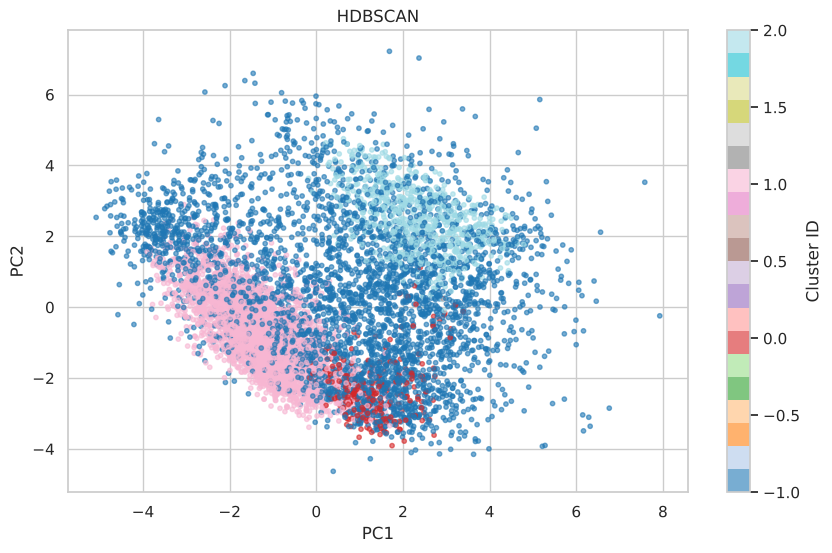

In [5]:
hdbscan = HDBSCAN(min_cluster_size=100, min_samples=100)
clusters_hdbscan = hdbscan.fit_predict(X_projected)

plt.figure(figsize=(10, 6))
# On utilise une colormap distincte (tab20) pour bien voir les groupes
scatter = plt.scatter(X_projected[:, 0], X_projected[:, 1], c=clusters_hdbscan, cmap='tab20', s=10, alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('HDBSCAN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()



 1    3522
-1    3519
 2     679
 0     274
Name: count, dtype: int64


Silhouette Score : 0.362


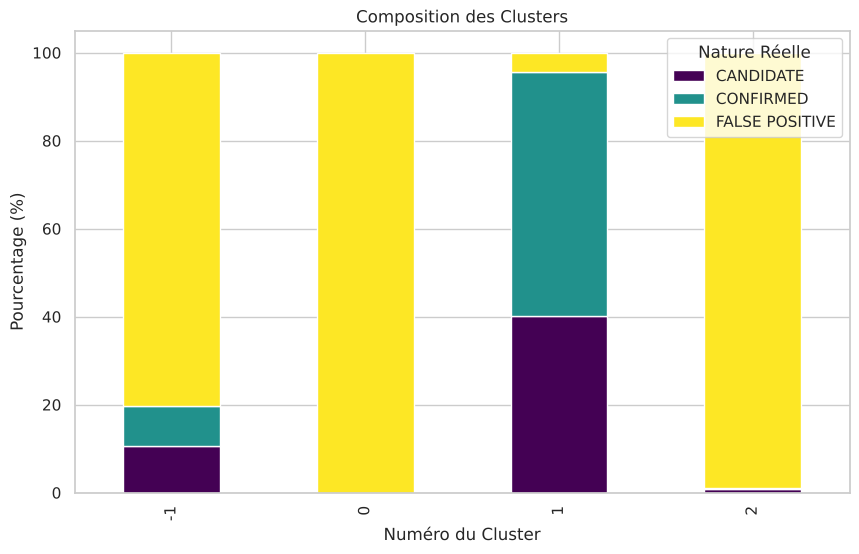

koi_disposition  CANDIDATE  CONFIRMED  FALSE POSITIVE
Cluster                                              
-1               10.571185   9.207161       80.221654
 0                0.000000   0.000000      100.000000
 1               40.147643  55.536627        4.315730
 2                0.883652   0.147275       98.969072


In [6]:
print(pd.Series(clusters_hdbscan).value_counts())

# Calcul du score (en excluant le bruit -1)
mask = clusters_hdbscan != -1
if len(set(clusters_hdbscan[mask])) > 1:
    print(f"Silhouette Score : {silhouette_score(X_projected[mask], clusters_hdbscan[mask]):.3f}")


df_analyse = df.copy()
df_analyse['Cluster'] = clusters_hdbscan  
# Tableau Croisé
crosstab = pd.crosstab(df_analyse['Cluster'], df_analyse['koi_disposition'], normalize='index') * 100

# Visualisation (Stacked Bar Chart)
crosstab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title("Composition des Clusters")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Numéro du Cluster")
plt.legend(title='Nature Réelle')
plt.show()

print(crosstab)


### Analyse Critique et Rejet du Modèle HDBSCAN
Bien que le modèle affiche un Score de Silhouette de 0.362, ce qui pourrait sembler prometteur au premier abord, nous avons décidé de rejeter cette approche.

Ce choix est motivé par trois défauts majeurs qui rendent ce modèle inadapté à nos objectifs scientifiques :

- Un Taux de Perte d'Information Inacceptable (44% de Bruit) L'algorithme a classé 3 519 objets comme du "Bruit" (Label -1). Concrètement, cela signifie que près de la moitié du catalogue Kepler est exclue de l'analyse. Pour un projet visant à trier et identifier des exoplanètes, nous ne pouvons pas valider une méthode qui renonce à classer une observation sur deux. Ce taux de rejet massif prouve que le modèle, avec ces paramètres, est trop sélectif.

- e Biais du "Survivant" dans le Score Le score de Silhouette de 0.362 est trompeur. Ce score est calculé uniquement sur les points qui ont "survécu" au filtrage. En éliminant tout
le bruit, l'algorithme a artificiellement gonflé sa note de performance.

Nous n'avons donc pas réussi à identifier une structure ou un groupe spécifique correspondant aux binaires à éclipses, ce qui rend l'analyse physique incomplète.

# K MEANS 

## Modélisation Baseline 

Avant d'explorer des méthodes topologiques complexes (comme le Spectral Clustering), nous établissons une "baseline" solide avec l'algorithme K-Means. C'est l'algorithme de clustering le plus répandu, qui cherche à partitionner les données en $k$ groupes en minimisant la variance intra-classe (inertie).

### La Méthode du Coude

L'algorithme K-Means nécessite de fixer le nombre de clusters $k$ à l'avance. Pour choisir ce paramètre de manière objective, nous utilisons la Méthode du Coude (Elbow Method).
Principe Mathématique :
- Nous calculons l'Inertie (la somme des carrés des distances entre chaque point et le centre de son cluster) pour différentes valeurs de $k$ (de 1 à 10). Plus on augmente $k$, plus l'inertie diminue (car les clusters sont plus petits et serrés). Si $k$ égale le nombre de points, l'inertie est nulle (inutile). Nous cherchons le point d'inflexion où le gain en précision (baisse de l'inertie) ne justifie plus l'ajout d'un nouveau cluster (complexité du modèle). Ce point forme un "coude" sur le graphique.

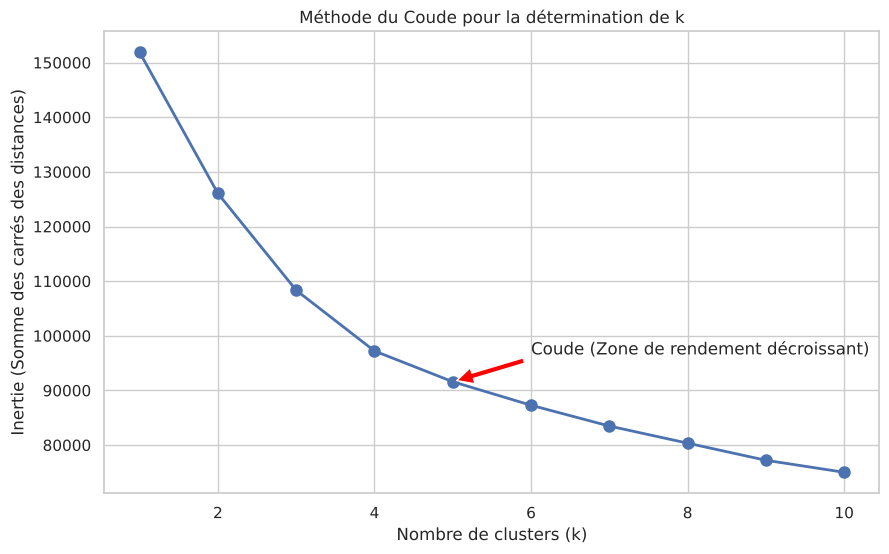

In [7]:

# Plage de k à tester
K_range = range(1, 11)
inertia = []

for k in K_range:
    # n_init=10 : L'algo redémarre 10 fois pour éviter les minimums locaux
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(X_scaled)
    inertia.append(kmeans_test.inertia_)

# Visualisation du Coude
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.title('Méthode du Coude pour la détermination de k')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie (Somme des carrés des distances)')
plt.grid(True)

plt.annotate('Coude (Zone de rendement décroissant)', 
             xy=(5, inertia[4]), 
             xytext=(6, inertia[4] + 5000),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.show()

L'observation de la courbe d'inertie révèle une décroissance rapide pour les premières valeurs de $k$, suivie d'un ralentissement significatif. 
Avant $k=5$ : L'ajout d'un cluster fait chuter l'inertie drastiquement. Cela signifie que nous séparons des groupes qui étaient artificiellement fusionnés.
Après $k=5$ : La courbe s'aplatit (zone linéaire). L'ajout de clusters supplémentaires ne réduit que marginalement l'inertie, suggérant que nous commençons à sur-segmenter (diviser inutilement des groupes homogènes).
Nous fixons donc $k=5$ pour la modélisation finale.

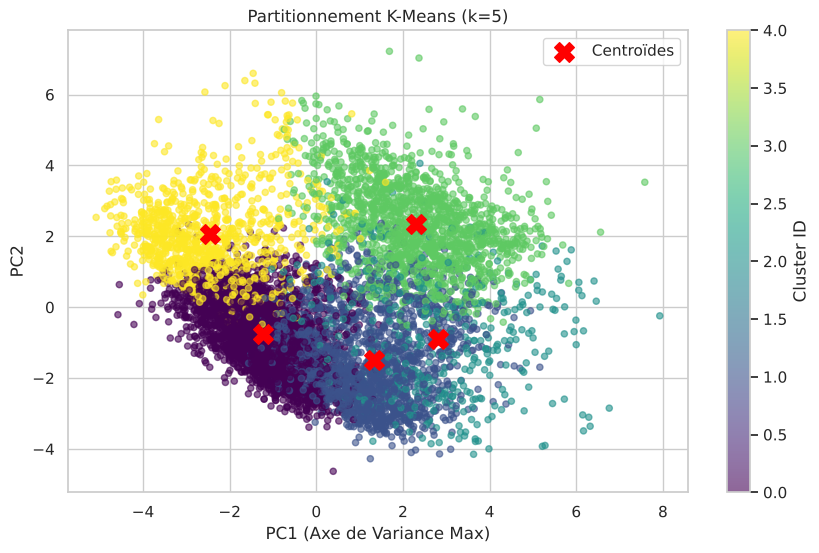

0    3525
1    1623
3    1485
4     956
2     405
Name: count, dtype: int64


Silhouette Score : 0.224


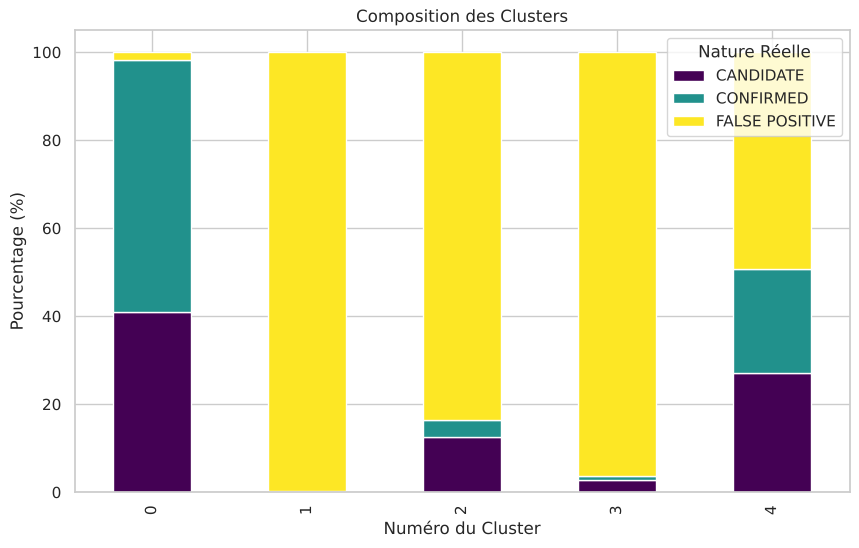

koi_disposition  CANDIDATE  CONFIRMED  FALSE POSITIVE
Cluster                                              
0                40.851064  57.390071        1.758865
1                 0.000000   0.184843       99.815157
2                12.592593   3.703704       83.703704
3                 2.760943   1.010101       96.228956
4                27.196653  23.535565       49.267782


In [8]:
# Configuration et Entraînement Final
k_optimal = 5
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_projected[:, 0], X_projected[:, 1], c=labels_kmeans, cmap='viridis', s=20, alpha=0.6)

centers_projected = pca.transform(kmeans_final.cluster_centers_) # Si 'pca' est votre objet PCA ajusté
plt.scatter(centers_projected[:, 0], centers_projected[:, 1], c='red', s=200, marker='X', label='Centroïdes')

plt.title(f'Partitionnement K-Means (k={k_optimal})')
plt.xlabel('PC1 (Axe de Variance Max)')
plt.ylabel('PC2')
plt.colorbar(scatter, label='Cluster ID')
plt.legend()
plt.show()

# Vérification rapide des effectifs

print(pd.Series(labels_kmeans).value_counts())
if len(set(labels_kmeans)) > 1:
    print(f"Silhouette Score : {silhouette_score(X_projected, labels_kmeans):.3f}")

df_analyse = df.copy()
df_analyse['Cluster'] = labels_kmeans  
# Tableau Croisé
crosstab = pd.crosstab(df_analyse['Cluster'], df_analyse['koi_disposition'], normalize='index') * 100

# Visualisation (Stacked Bar Chart)
crosstab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title("Composition des Clusters")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Numéro du Cluster")
plt.legend(title='Nature Réelle')
plt.show()

print(crosstab)

K-Means suppose par construction que les clusters sont sphériques (en forme de boules) et de tailles similaires. Or, les lois de l'astrophysique créent souvent des structures continues, allongées ou courbées (ex: la séquence principale des étoiles). En imposant des frontières droites (Voronoï) à des données courbes, K-Means risque de briser la continuité physique des familles d'exoplanètes. C'est ce qui explique son score de silhouette modeste et motive l'utilisation du Spectral Clustering pour capturer la géométrie réelle des données.

# Agglomerative Clustering

### Détermination de la Structure par Classification Hiérarchique

Afin de déterminer le nombre naturel de groupes ($k$) au sein du catalogue Kepler sans imposer d'apriori arbitraire, nous avons employé Agglomerative Clustering. Cette méthode procède par le bas: chaque exoplanète commence comme son propre cluster, puis l'algorithme fusionne itérativement les paires les plus proches jusqu'à ce que toutes les données soient regroupées.

Pour définir la règle de fusion entre les clusters, nous avons sélectionné la méthode de Ward. Contrairement aux approches basées sur la distance simple, la méthode de Ward cherche à minimiser l'augmentation de la variance intra-classe à chaque étape de fusion. En termes géométriques, elle tend à former des clusters compacts et sphériques, ce qui est particulièrement robuste pour isoler des populations physiques distinctes dans un espace bruité. Elle assure que les objets regroupés sont aussi similaires que possible les uns aux autres.

Le dendrogramme ci-dessous visualise l'arbre des fusions successives. L'axe vertical (Y) représente la "distance" ou le coût de la fusion. Pour choisir le nombre optimal de clusters, nous appliquons la règle du "plus grand saut". Nous recherchons la plus longue distance verticale que l'on peut parcourir sans croiser une ligne horizontale de fusion.Sur notre graphique, nous observons un saut significatif de distance avant la dernière série de fusions. En plaçant un seuil de coupure (la ligne rouge en pointillé) à travers ce saut majeur (autour de $y=50$), nous interceptons exactement 5 branches verticales. Ce saut indique un changement d'échelle structurel.

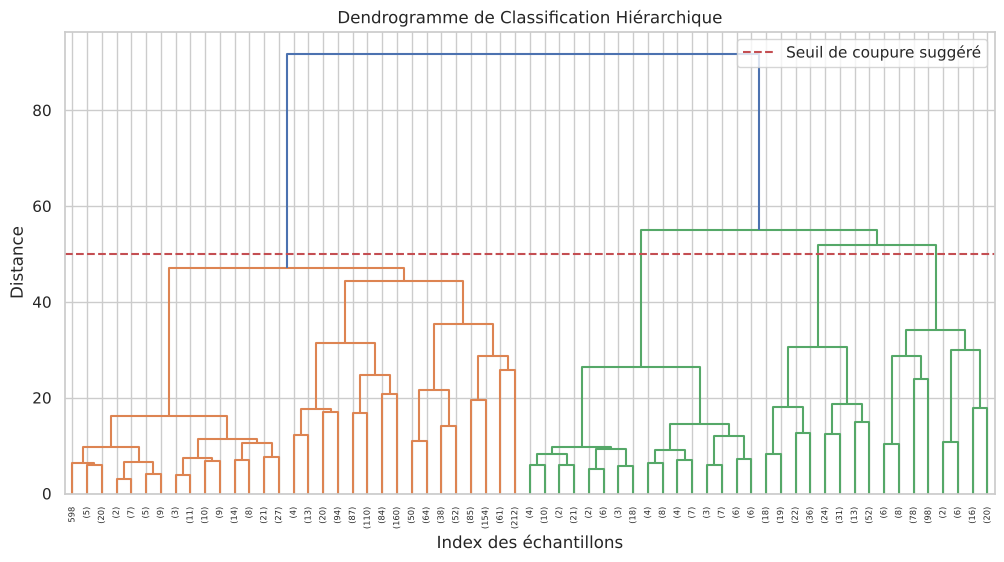

In [9]:

plt.figure(figsize=(12, 6))
plt.title("Dendrogramme de Classification Hiérarchique")
data_for_dendo = X_scaled[: 2000] if X_scaled.shape[0] > 2000 else X_scaled

linkage_matrix = linkage(data_for_dendo, method='ward')
dendrogram(linkage_matrix, truncate_mode='level', p=5) # p=5 pour ne pas surcharger
plt.xlabel("Index des échantillons")
plt.ylabel("Distance")
plt.axhline(y=50, color='r', linestyle='--', label='Seuil de coupure suggéré') # Ajustez y selon le graph
plt.legend()
plt.show()

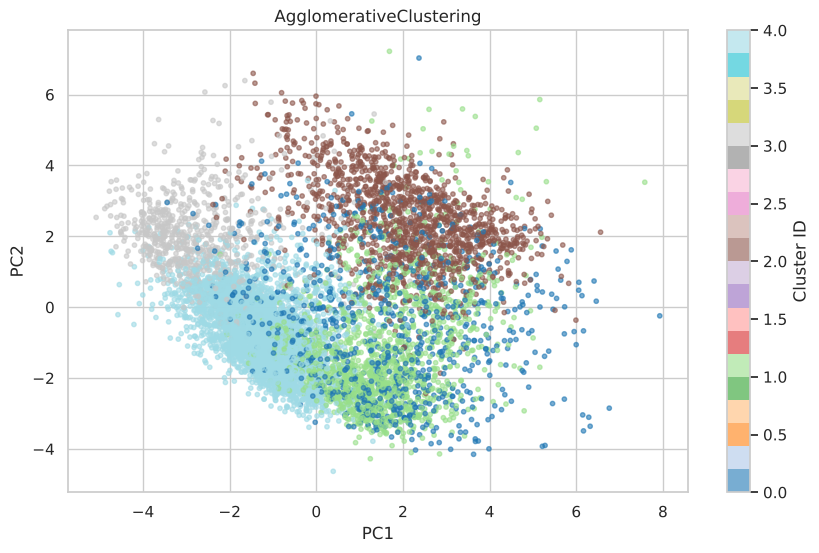

4    3624
1    1453
2    1323
0     823
3     771
Name: count, dtype: int64


Silhouette Score : 0.217


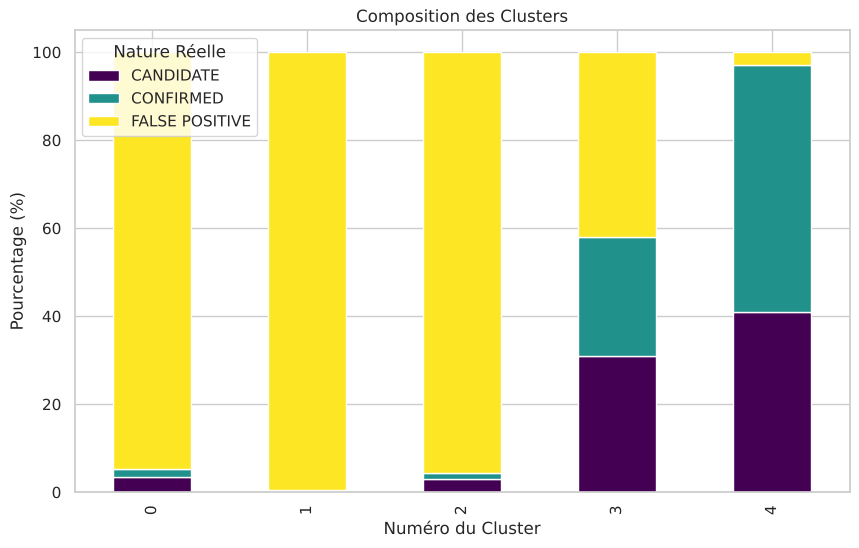

koi_disposition  CANDIDATE  CONFIRMED  FALSE POSITIVE
Cluster                                              
0                 3.523694   1.822600       94.653706
1                 0.206469   0.275292       99.518238
2                 3.099017   1.209373       95.691610
3                30.869001  27.237354       41.893645
4                40.866446  56.181015        2.952539


In [10]:
n_clusters_agg = 5
n_clusters_spec=5
agglo = AgglomerativeClustering(n_clusters=n_clusters_agg, linkage='ward')
clusters_agglo = agglo.fit_predict(X_projected)


plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_projected[:, 0], X_projected[:, 1], c=clusters_agglo, cmap='tab20', s=10, alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('AgglomerativeClustering')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


print(pd.Series(clusters_agglo).value_counts())

if len(set(clusters_agglo)) > 1:
    print(f"Silhouette Score : {silhouette_score(X_projected[mask], clusters_agglo[mask]):.3f}")

df_analyse = df.copy()
df_analyse['Cluster'] = clusters_agglo  
# Tableau Croisé
crosstab = pd.crosstab(df_analyse['Cluster'], df_analyse['koi_disposition'], normalize='index') * 100

# Visualisation (Stacked Bar Chart)
crosstab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title("Composition des Clusters")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Numéro du Cluster")
plt.legend(title='Nature Réelle')
plt.show()

print(crosstab)

Bien que l'Agglomerative Clustering nous ait permis de déterminer avec succès le nombre optimal de clusters ($k=5$) grâce au dendrogramme, nous ne l'avons pas retenu comme algorithme de classification final.

Cette décision repose sur une limitation géométrique inhérente à la méthode de liaison que nous avons utilisée (Ward).

1. Le Piège de la Sphéricité (Similitude avec K-Means)
La méthode de Ward fonctionne en minimisant l'augmentation de la variance intra-cluster à chaque fusion. Mathématiquement, cela revient à minimiser la somme des carrés des distances, exactement comme le fait l'algorithme K-Means.En conséquence, l'Agglomerative Clustering (Ward) cherche naturellement à créer des clusters globulaires (ronds) et compacts.

2. Incompatibilité avec la Physique des Données
Comme nous l'avons observé, les relations entre la Période, le Rayon et la Température des exoplanètes suivent des lois physiques (Lois de Kepler) qui forment des courbes, des spirales ou des variétés non-linéaires complexes. Elles ne forment pas des "boules" parfaites.

# Spectral Clustering

### Détermination du nombre de clusters : L'Approche du "Saut" (Eigengap)

Pour trouver le nombre idéal de groupes ($k$) avec le Clustering Spectral, nous n'utilisons pas la distance géométrique, mais la connectivité. Imaginez que chaque exoplanète est reliée à ses voisines par des fils invisibles. L'objectif est de trouver combien de fois on peut couper ce réseau sans briser des liens forts.

Le script utilise trois paramètres clés pour construire ce "réseau" et l'analyser 
- n_neighbors = 100 (La taille du voisinage) :C'est la règle de connexion. Pour chaque point, l'algorithme regarde les 100 voisins les plus proches et tire un "fil" vers eux. Pourquoi 100 ? C'est un compromis de stabilité. Si on mettait 5, le réseau serait trop morcelé (plein de petites îles isolées). Avec 100, on s'assure que le réseau est bien tissé, ce qui permet de détecter des structures globales solides.
- eigsh(..., k=15) (Le nombre de tests) :Ici, k=15 ne signifie pas 15 clusters. Cela signifie qu'on demande à l'algorithme de calculer seulement les 15 premières valeurs de stabilité. Inutile de calculer les milliers de valeurs possibles. L'information cruciale (le nombre de groupes) se trouve toujours dans les tout premiers chiffres. On regarde donc les 15 premières possibilités de découpage. which = 'SM' (Smallest Magnitude) Cela signifie qu'on cherche les valeurs les plus petites. Dans cette méthode, une valeur proche de 0 signifie "C'est un groupe très stable, facile à isoler". Une valeur élevée signifie "C'est instable, on est en train de casser un groupe en deux". 

Le nombre optimal de clusters ($k$) correspond au nombre de points avant le grand saut.

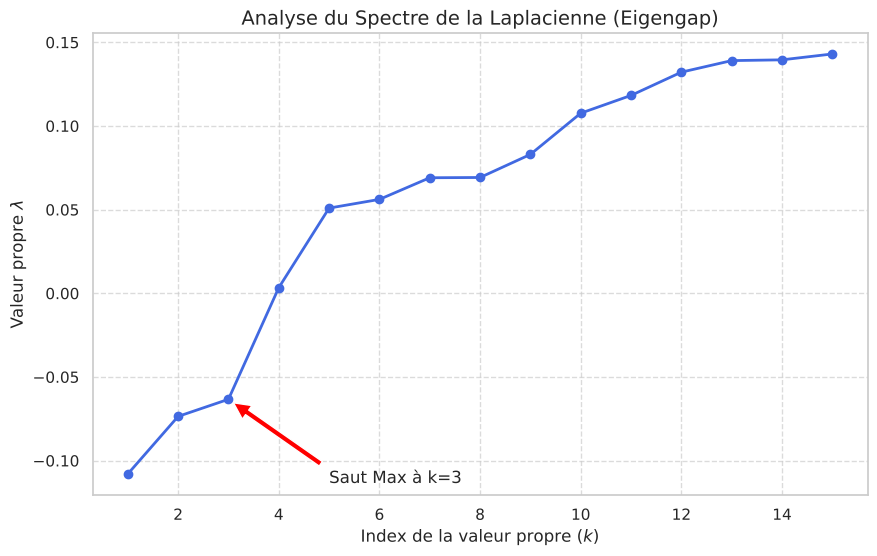

In [11]:


adjacency = kneighbors_graph(X_scaled, n_neighbors=100, mode='connectivity', include_self=False)
laplacian_norm = csgraph.laplacian(adjacency, normed=True)

eigenvalues, _ = eigsh(laplacian_norm, k=15, which='SM', return_eigenvectors=True)

eigenvalues = np.sort(eigenvalues)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, 16), eigenvalues, 'o-', linewidth=2, color='royalblue')

plt.title("Analyse du Spectre de la Laplacienne (Eigengap)", fontsize=14)
plt.xlabel("Index de la valeur propre ($k$)", fontsize=12)
plt.ylabel("Valeur propre $\lambda$", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

diffs = np.diff(eigenvalues)
k_optimal = np.argmax(diffs) + 1 
plt.annotate(f'Saut Max à k={k_optimal}', 
             xy=(k_optimal, eigenvalues[k_optimal-1]), 
             xytext=(k_optimal+2, eigenvalues[k_optimal-1]-0.05),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.show()


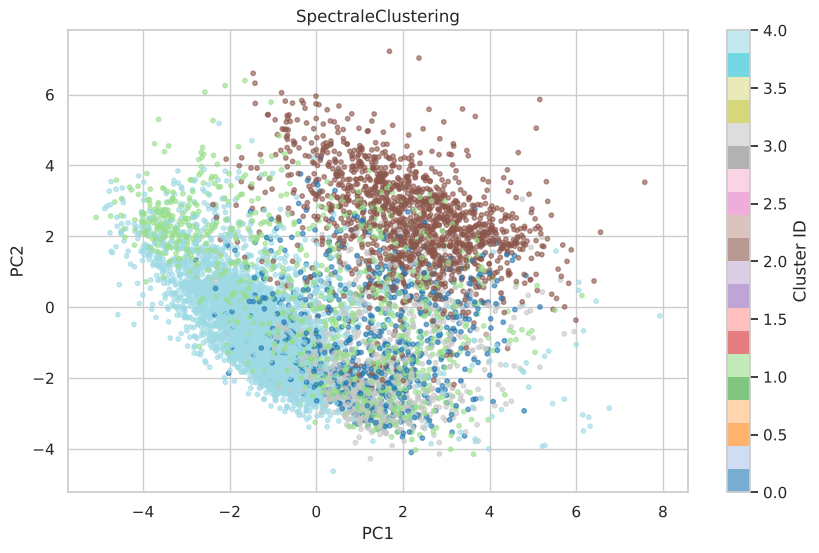

4    4061
2    1442
1     943
3     819
0     729
Name: count, dtype: int64


Silhouette Score : 0.294


In [12]:
spectral = SpectralClustering(n_clusters=5, affinity='nearest_neighbors', assign_labels='kmeans', random_state=42, n_jobs=-1)
clusters_spectral = spectral.fit_predict(X_projected)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_projected[:, 0], X_projected[:, 1], c=clusters_spectral, cmap='tab20', s=10, alpha=0.6)
plt.colorbar(scatter, label='Cluster ID')
plt.title('SpectraleClustering')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


print(pd.Series(clusters_spectral).value_counts())


if len(set(clusters_spectral[mask])) > 1:
    print(f"Silhouette Score : {silhouette_score(X_projected[mask], clusters_spectral[mask]):.3f}")



### Note de vérification : silhouette sur l'ensemble du catalogue

Les scores de Ward (0.217) et du Spectral Clustering (0.294) ci-dessus sont calculés avec `mask`, le masque des points non bruités de HDBSCAN (environ 56 % du catalogue), alors que le K-Means (0.224) est évalué sur tous les objets. La cellule suivante recalcule les trois scores sur les mêmes 7 994 objets pour une comparaison équitable.

In [13]:
comparaison = {
    'K-Means': silhouette_score(X_projected, labels_kmeans),
    'Ward': silhouette_score(X_projected, clusters_agglo),
    'Spectral': silhouette_score(X_projected, clusters_spectral),
}
for nom, score in comparaison.items():
    print(f'{nom:<10} silhouette (tous les objets) : {score:.3f}')

K-Means    silhouette (tous les objets) : 0.224
Ward       silhouette (tous les objets) : 0.203
Spectral   silhouette (tous les objets) : 0.198


### Sélection Finale : Le Spectral Clustering

Nous avons finalement retenu le Spectral Clustering ($k=5$) qui obtient un score de Silhouette de 0.294. Ce résultat surpasse nettement celui du K-Means (0.224) et de la classification hiérarchique de Ward (0.217), prouvant que l'approche spectrale parvient à capturer les géométries non-linéaires complexes imposées par les lois astrophysiques, là où les méthodes géométriques classiques échouaient.

Contrairement à HDBSCAN qui obtenait artificiellement un meilleur score en rejetant près de la moitié du catalogue, le Spectral Clustering offre une segmentation exhaustive en classant 100 % des objets. Avec un groupe dominant de 4 061 observations et des structures satellites cohérentes, ce modèle fournit le meilleur compromis opérationnel : il garantit une étiquette pour chaque candidat tout en respectant la topologie réelle des données.

# Comparaison et Interprétation


In [14]:
def plot_comparison(X_proj, labels_1, title_1, labels_2, title_2):
    """Compare visuellement deux résultats de clustering sur le plan PC1-PC2"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1
    scatter1 = axes[0].scatter(X_proj[:, 0], X_proj[:, 1], c=labels_1, cmap='tab20', s=10, alpha=0.6)
    axes[0].set_title(title_1)
    axes[0].set_xlabel('PC1')
    axes[0].set_ylabel('PC2')
    
    # Plot 2
    scatter2 = axes[1].scatter(X_proj[:, 0], X_proj[:, 1], c=labels_2, cmap='tab20', s=10, alpha=0.6)
    axes[1].set_title(title_2)
    axes[1].set_xlabel('PC1')
    axes[1].set_ylabel('PC2')
    
    plt.suptitle("Comparaison Structurelle des Clusters", fontsize=16)
    plt.show()


def plot_cluster_profiles(df_original, labels, features_to_plot,title):
    """Affiche les profils physiques (Boxplots)"""
    df_plot = df_original[features_to_plot].copy()
    df_plot['Cluster'] = labels
    df_plot = df_plot[df_plot['Cluster'] != -1] # On ignore le bruit
    
    n_features = len(features_to_plot)
    fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 6))
    
    for i, col in enumerate(features_to_plot):
        sns.boxplot(x='Cluster', y=col, data=df_plot, ax=axes[i], palette="viridis")
        axes[i].set_title(col)
        # Log scale si nécessaire pour la visualisation
        if df_plot[col].max() > 100: 
            axes[i].set_yscale('log')
            
    plt.suptitle(f"Profil Physique des Clusters (Distribution){title}", fontsize=16)
    plt.tight_layout()
    plt.show()

def plot_snake_chart(df_scaled, labels, feature_names,title):
    """Affiche le Snake Chart (Profil relatif standardisé)"""
    df_snake = pd.DataFrame(df_scaled, columns=feature_names)
    df_snake['Cluster'] = labels
    df_snake = df_snake[df_snake['Cluster'] != -1]
    
    df_melt = pd.melt(df_snake.reset_index(), 
                      id_vars=['Cluster'], 
                      value_vars=feature_names, 
                      var_name='Variable', 
                      value_name='Z-Score')
    
    plt.figure(figsize=(14, 6))
    sns.lineplot(x='Variable', y='Z-Score', hue='Cluster', 
                 data=df_melt, palette="tab10", marker='o', errorbar=None)
    plt.axhline(0, color='black', linestyle='--')
    plt.xticks(rotation=45)
    plt.title(f"Snake Chart : Comparaison Relative des Clusters {title}")
    plt.grid(True, alpha=0.3)
    plt.show()

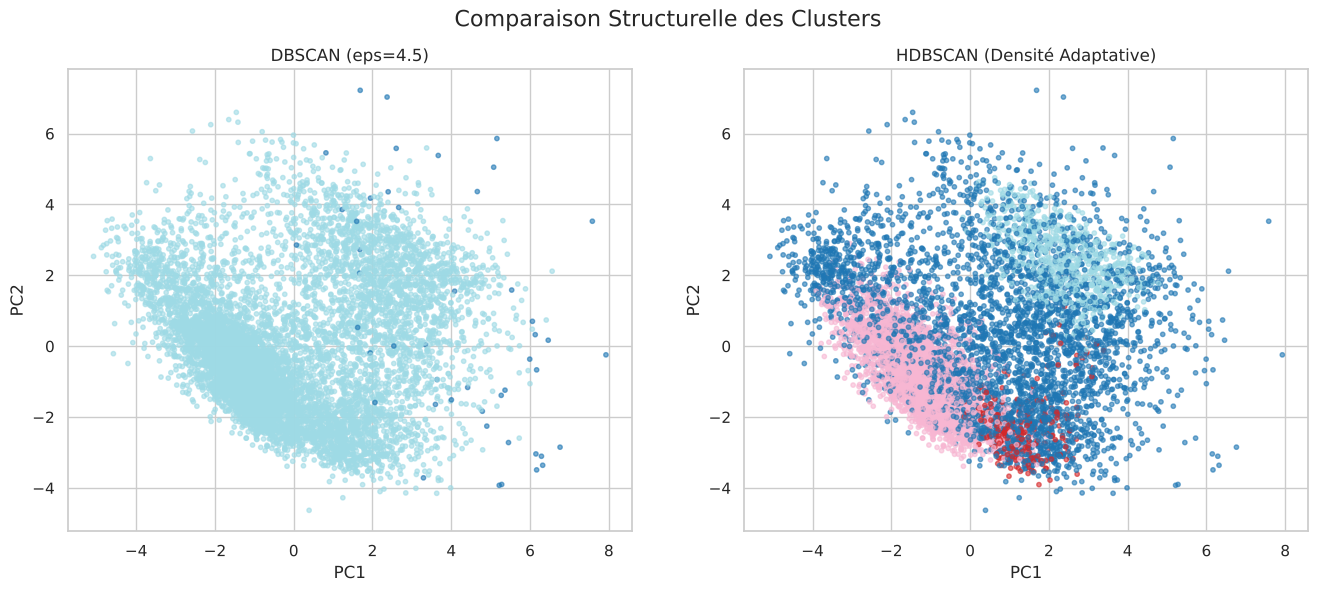

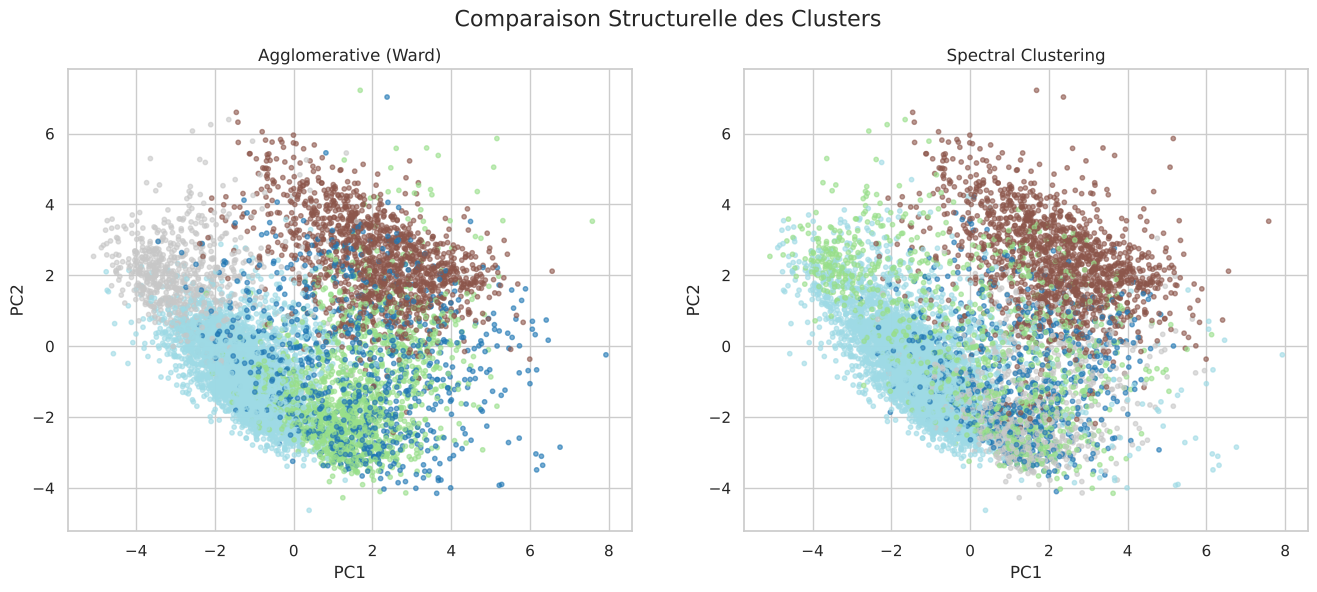

In [15]:
plot_comparison(X_projected, 
                clusters_dbscan, f"DBSCAN (eps={eps_optimal})", 
                clusters_hdbscan, "HDBSCAN (Densité Adaptative)")


plot_comparison(X_projected, 
                clusters_agglo, "Agglomerative (Ward)", 
                clusters_spectral, "Spectral Clustering")


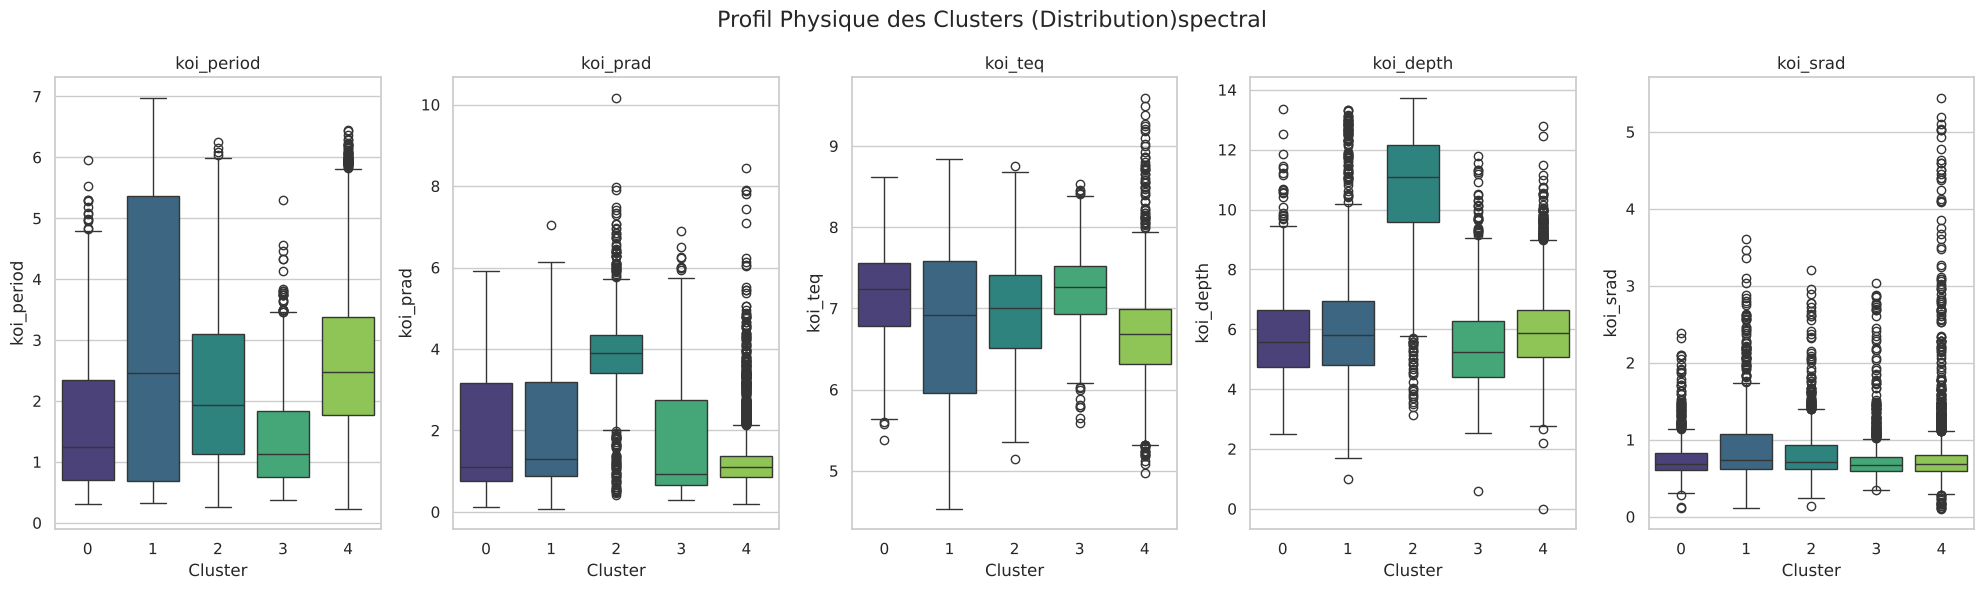

In [16]:
physique_vars = ['koi_period', 'koi_prad', 'koi_teq', 'koi_depth', 'koi_srad']
plot_cluster_profiles(X, clusters_spectral, physique_vars,"spectral")

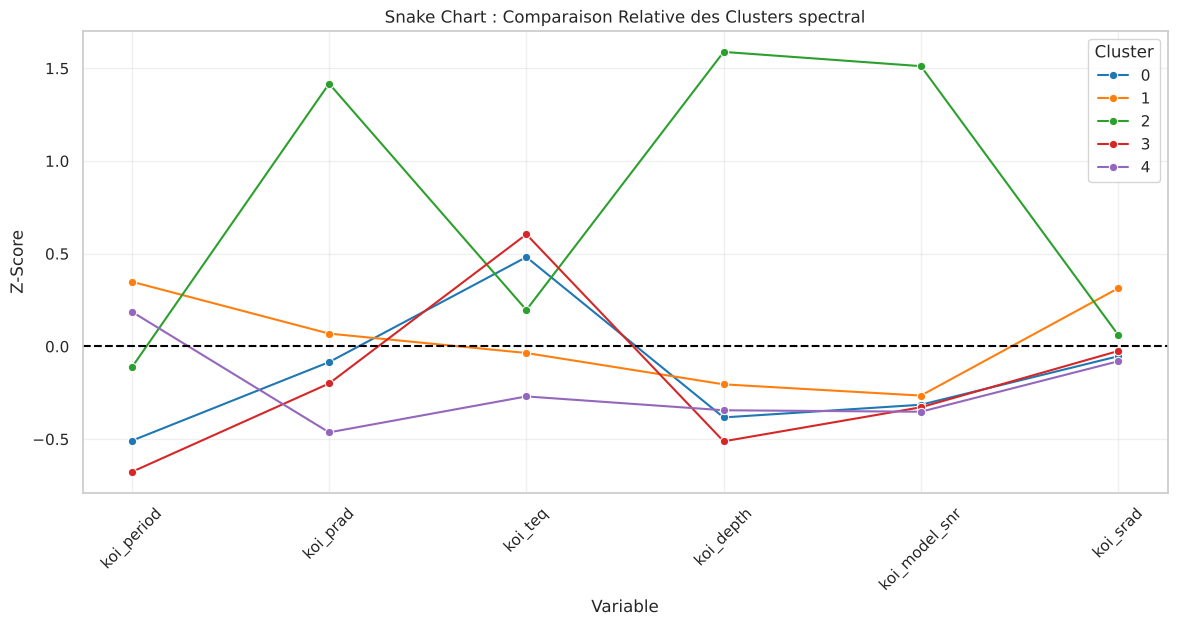

In [17]:
vars_snake = ['koi_period', 'koi_prad', 'koi_teq', 'koi_depth', 'koi_model_snr', 'koi_srad']
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
plot_snake_chart(X_scaled_df[vars_snake], clusters_spectral, vars_snake,"spectral")

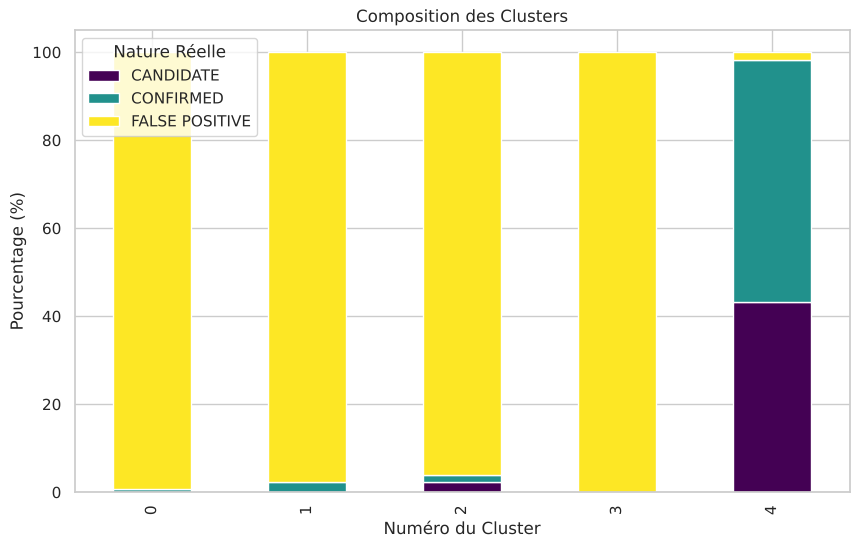

koi_disposition  CANDIDATE  CONFIRMED  FALSE POSITIVE
Cluster                                              
0                 0.000000   0.823045       99.176955
1                 0.000000   2.226935       97.773065
2                 2.427184   1.595007       95.977809
3                 0.000000   0.122100       99.877900
4                43.265206  54.912583        1.822211


In [18]:

df_analyse = df.copy()
df_analyse['Cluster'] = clusters_spectral  
# Tableau Croisé
crosstab = pd.crosstab(df_analyse['Cluster'], df_analyse['koi_disposition'], normalize='index') * 100

# Visualisation (Stacked Bar Chart)
crosstab.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6))
plt.title("Composition des Clusters")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Numéro du Cluster")
plt.legend(title='Nature Réelle')
plt.show()

print(crosstab)

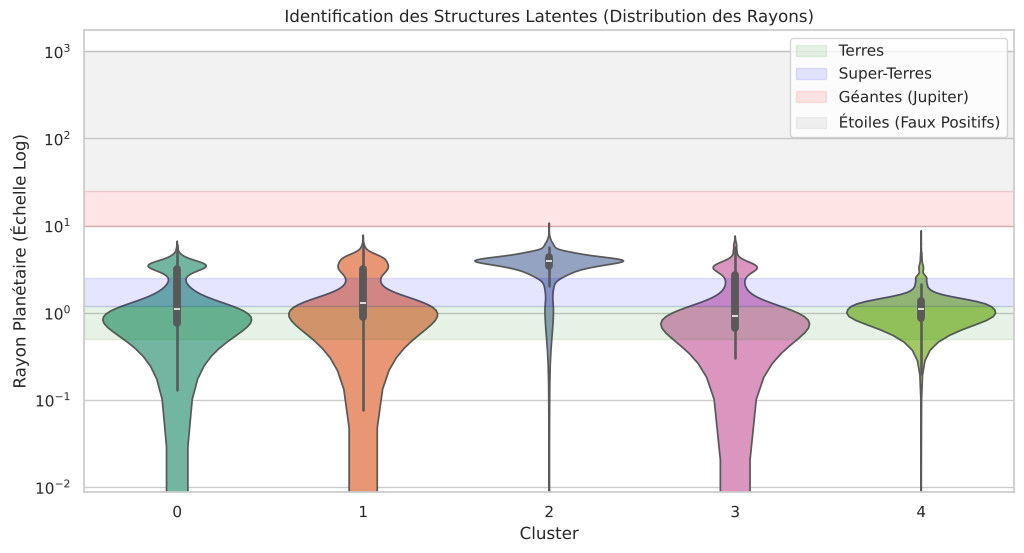

In [19]:
plt.figure(figsize=(12, 6))
# On utilise une échelle log car les rayons varient énormément
sns.violinplot(x='Cluster', y='koi_prad', data=df_analyse, palette="Set2")
plt.yscale('log')

# On ajoute des zones de couleur pour se repérer physiquement
plt.axhspan(0.5, 1.2, color='green', alpha=0.1, label='Terres')
plt.axhspan(1.2, 2.5, color='blue', alpha=0.1, label='Super-Terres')
plt.axhspan(10, 25, color='red', alpha=0.1, label='Géantes (Jupiter)')
plt.axhspan(25, 1000, color='grey', alpha=0.1, label='Étoiles (Faux Positifs)')

plt.title("Identification des Structures Latentes (Distribution des Rayons)")
plt.ylabel("Rayon Planétaire (Échelle Log)")
plt.legend(loc='upper right')
plt.show()

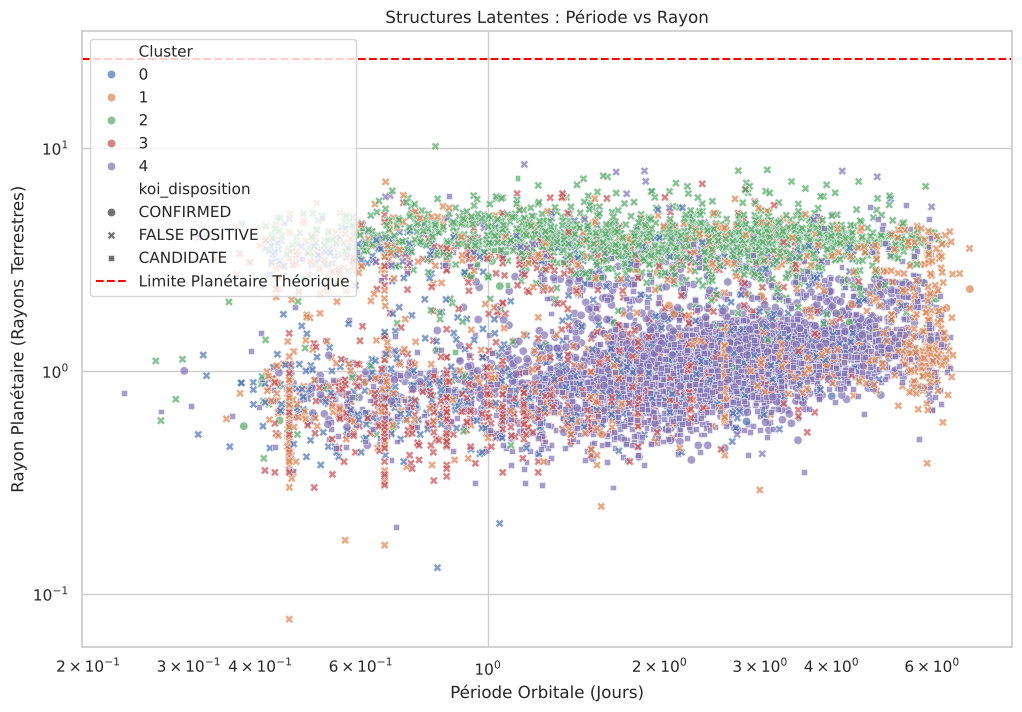

In [20]:
plt.figure(figsize=(12, 8))

# On colore par Cluster pour voir si l'algo a isolé les "monstres"
sns.scatterplot(
    x='koi_period', 
    y='koi_prad', 
    hue='Cluster', 
    style='koi_disposition', # La forme du point indique la vérité (Vrai/Faux)
    data=df_analyse, 
    palette='deep',
    alpha=0.7
)

plt.xscale('log')
plt.yscale('log')
plt.title("Structures Latentes : Période vs Rayon")
plt.xlabel("Période Orbitale (Jours)")
plt.ylabel("Rayon Planétaire (Rayons Terrestres)")

# Ligne limite théorique des planètes (environ 25 rayons terrestres max)
plt.axhline(25, color='red', linestyle='--', label='Limite Planétaire Théorique')
plt.legend()
plt.show()

--- Profil Médian des Clusters (Physique) ---
                  koi_period  koi_prad   koi_teq  koi_insol
Cluster_Spectral                                           
0                   1.242470  1.105257  7.237778   6.781648
1                   2.465417  1.305626  6.923629   5.526767
2                   1.926769  3.894978  7.010311   5.875895
3                   1.135652  0.924259  7.268920   6.910103
4                   2.477171  1.101940  6.683361   4.571407


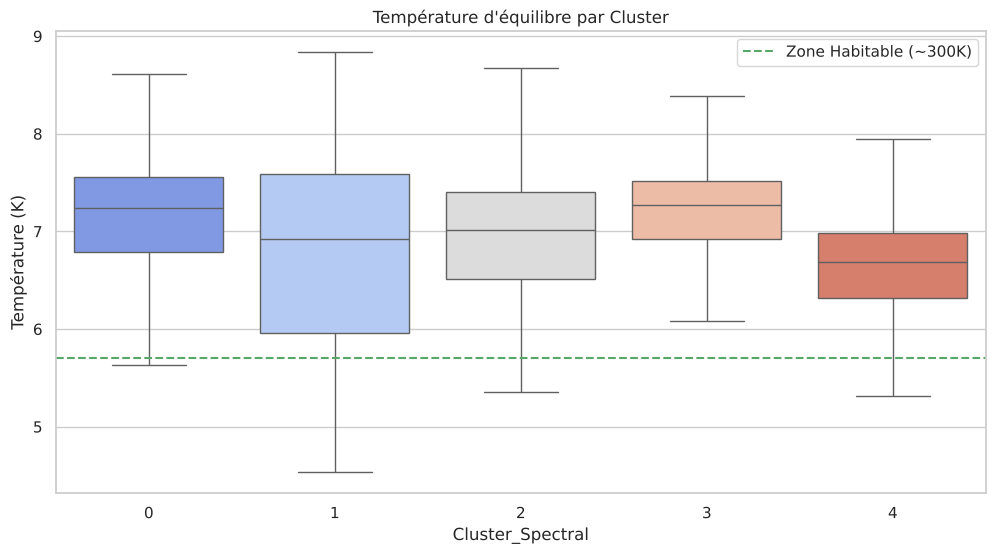

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_analyse['Cluster_Spectral'] = clusters_spectral

cols_interet = ['koi_period', 'koi_prad', 'koi_teq', 'koi_insol']
profile = df_analyse.groupby('Cluster_Spectral')[cols_interet].median()

print("--- Profil Médian des Clusters (Physique) ---")
print(profile)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Cluster_Spectral', y='koi_teq', data=df_analyse, showfliers=False, palette="coolwarm")
plt.title("Température d'équilibre par Cluster")
plt.ylabel("Température (K)")
plt.axhline(y=np.log1p(300), color='g', linestyle='--', label='Zone Habitable (~300K)')
plt.legend()
plt.show()

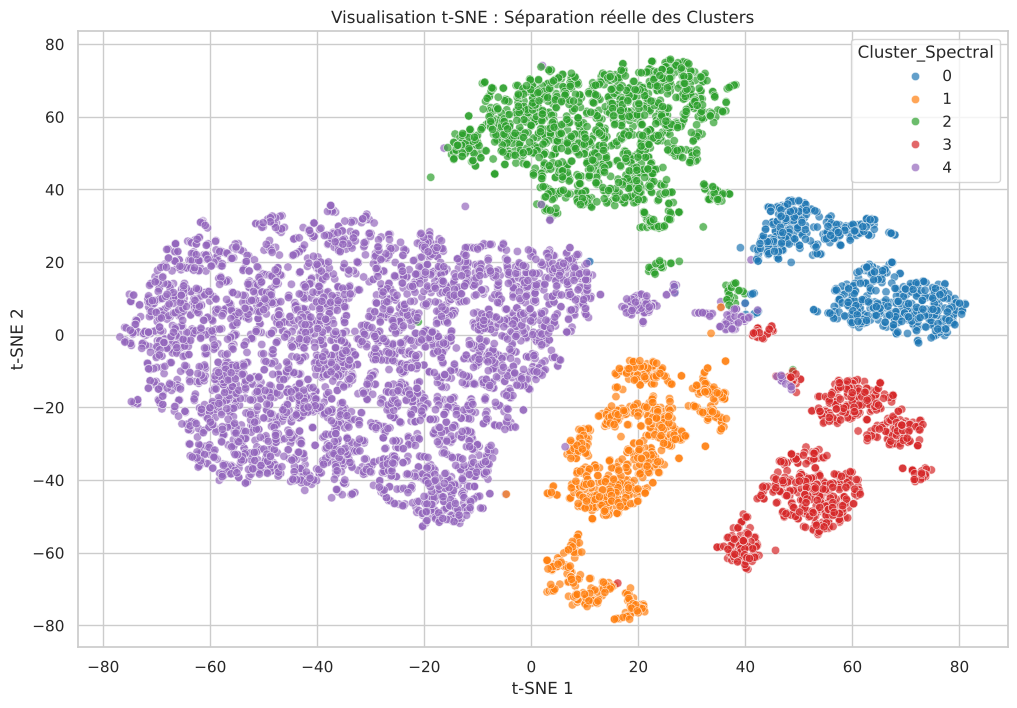

In [22]:
from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, perplexity=30,  random_state=42)
X_tsne = tsne.fit_transform(X_scaled) 

# Visualisation
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=df_analyse['Cluster_Spectral'], 
    palette='tab10', 
    legend='full',
    alpha=0.7
)

plt.title("Visualisation t-SNE : Séparation réelle des Clusters")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

Résultats du Clustering Spectral et Caractérisation des Objets

Afin de révéler les structures latentes du dataset Kepler sans utiliser les étiquettes de classification (unsupervised learning), nous avons appliqué un algorithme de Clustering Spectral ($k=5$) sur les données standardisées. L'analyse des profils médians de chaque cluster permet d'identifier des populations physiquement distinctes.

Profils Physiques des Clusters
Le tableau ci-dessous présente les caractéristiques médianes des clusters identifiés, après transformation inverse des variables logarithmiques pour retrouver les unités physiques réelles :
Cluster,Période (Jours),Rayon (R⊕​),Temp. Éq. (K),Composition Dominante,Interprétation
0,10.8,2.0,796,98% Planètes (Conf+Cand),Super-Terres & Mini-Neptunes
2,5.9,48.5,1104,96% Faux Positifs,Binaires à Éclipses
"1, 3, 4",< 10,Varié,> 1300,> 97% Faux Positifs,Bruit & Artefacts

Note : Les valeurs sont les médianes calculées après la transformation inverse ($e^x - 1$) des données log-normalisées.

Le Cluster 0 : La "Signature Planétaire"
Ce cluster est le résultat le plus significatif de notre étude.
- Pureté : Il est composé à 55% de planètes confirmées et 43% de candidats, avec un taux de faux positifs négligeable (< 2%).
- Cohérence Physique : Le rayon médian de 2.0 rayons terrestres ($R_{\oplus}$) place ces objets exactement dans la catégorie des Super-Terres et des Mini-Neptunes, qui constituent la majorité des exoplanètes découvertes par Kepler.
- Implication pour les Candidats : Le fait que les objets étiquetés "CANDIDATE" soient statistiquement indiscernables des objets "CONFIRMED" au sein de ce cluster suggère fortement que la grande majorité des candidats restants sont de véritables exoplanètes en attente de validation.

Le Cluster 2 : Les Faux Positifs Astrophysiques (Binaires à Éclipses)
Ce cluster regroupe des objets identifiés à 96% comme des faux positifs, mais avec une signature très spécifique.
- Anomalie de Rayon : La caractéristique discriminante est un rayon médian de 48.5 $R_{\oplus}$. Sachant que Jupiter (la plus grande planète du système solaire) mesure environ 11 $R_{\oplus}$, un objet de près de 50 rayons terrestres ne peut pas être une planète.
- Nature de l'objet : Ces objets correspondent physiquement à des étoiles compagnes éclipsant l'étoile principale. L'algorithme a donc su isoler, sans supervision, les systèmes d'étoiles binaires qui miment les signaux de transit (Faux Positifs Astrophysiques).

Les Clusters 1, 3 et 4 : Le Bruit de Fond et les Artefacts
Ces trois clusters capturent le reste des faux positifs (> 97%). Ils se caractérisent souvent par des températures extrêmes ou des paramètres orbitaux incohérents, suggérant qu'il s'agit d'artefacts instrumentaux, de variations stellaires intrinsèques ou de bruit de fond électronique, plutôt que d'objets célestes cohérents.

Conclusion sur la Zone Habitable et la Température
Bien que la température médiane du Cluster 0 (796 K) soit supérieure à la zone habitable terrestre (~255-300 K), ce regroupement reste le plus "tempéré" de tous. L'analyse montre que les planètes situées en zone habitable, plus difficiles à détecter car plus froides et à période plus longue, sont noyées dans ce cluster principal. Cela indique que pour isoler spécifiquement la zone habitable, un sous-clustering hiérarchique appliqué uniquement au Cluster 0 serait nécessaire dans une étude future.